# CAA Linear Manifold Continuity Test

**仮説**: LLM内部の感情表現は「8つの離散点」ではなく、**線形・連続的な多様体**上に存在する。
感情ラベルはその多様体上の原型領域への後付けに過ぎない。

**CAAを使う理由**: CAAベクトルは `mean_n(h_emotion[n] - h_neutral[n])` の定義により、
- ソーステキストの文体・語彙・テーマを除去済み
- 純粋に「ニュートラルパラフレーズから感情Xへの変化方向」を表す
- これにより感情変化そのものの線形構造が検証しやすい

**分析内容**:
1. **対称性テスト**: `v(A→B) ≈ -v(B→A)` か？（感情変化は可逆か？）
2. **推移性テスト**: `v(A→B) + v(B→C) ≈ v(A→C)` か？（感情空間は加法的か？）
3. **線形補間テスト**: 感情AとBの中間点は実際にその感情の混合に見えるか？
4. **Circumplex モデル適合**: 感情方向は2D円上に並ぶか（VADモデル）？
5. **感情の埋め込み可能性**: 全感情を最小次元で埋め込める次元は？

**入力**: `activation/emotion_rewrites/caa_emotion_directions.npz`

**出力**: `analysis/caa/manifold_linearity/`

**対応する既存ノートブック**: `continuous_affect_hypothesis.ipynb` の Phase B, C, D に相当（残差ストリームではなく CAA ベクトルで直接実施）


## 0. Setup

In [1]:
from __future__ import annotations

import json
import warnings
from itertools import permutations, combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import minimize
from scipy.stats import spearmanr, pearsonr
from sklearn.decomposition import PCA
from sklearn.manifold import MDS

warnings.filterwarnings('ignore')

REPO_ROOT = Path('../..').resolve()
ACT_DIR   = REPO_ROOT / 'activation' / 'emotion_rewrites'
CAA_PATH  = ACT_DIR / 'caa_emotion_directions.npz'
INFO_PATH = ACT_DIR / 'caa_emotion_directions_info.json'
OUT_DIR   = REPO_ROOT / 'analysis' / 'caa' / 'manifold_linearity'
OUT_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY_LAYER = 13

sns.set_context('notebook')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150})
print('OUT_DIR =', OUT_DIR)

OUT_DIR = /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/manifold_linearity


In [2]:
with open(INFO_PATH) as f:
    INFO = json.load(f)

EMOTION_ORDER   = INFO['emotion_order']
INTENSITY_ORDER = INFO['intensity_order']
LAYER_INDICES   = INFO['layer_indices']
LI_MAP          = {l: i for i, l in enumerate(LAYER_INDICES)}
N_EMO           = len(EMOTION_ORDER)
EMO_POS         = {e: i for i, e in enumerate(EMOTION_ORDER)}

data       = np.load(CAA_PATH)
CAA_POOLED = data['caa_pooled']   # (8, 6, 4096)  unit-normed
DELTA_MEAN = data['delta_mean']   # (8, 3, 6, 4096)  raw magnitude
D = CAA_POOLED.shape[-1]

def get_pooled(layer: int) -> np.ndarray:
    return CAA_POOLED[:, LI_MAP[layer], :]  # (8, D)

def unit(v: np.ndarray) -> np.ndarray:
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return v / (n + 1e-12)

def cos_sim(a: np.ndarray, b: np.ndarray) -> float:
    return float(unit(a) @ unit(b))

print(f'EMOTION_ORDER: {EMOTION_ORDER}')
print(f'LAYER_INDICES: {LAYER_INDICES}  (primary={PRIMARY_LAYER})')

EMOTION_ORDER: ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']
LAYER_INDICES: [8, 10, 13, 16, 19, 22]  (primary=13)


---
## 1. 感情間遷移ベクトルの定義

CAAベクトル自体は「ベーステキストから感情Xへの変化方向」を表す。
したがって「感情AからBへの変化」は:

$$v_{A \to B} = \text{caa}(B) - \text{caa}(A)$$

と定義できる。これはつまり「A方向の感情から、B方向の感情に向かうベクトル」。

**Note**: `delta_mean` (単位正規化前) の方が大きさの情報を保持しているため、大きさが意味を持つ分析では `delta_mean` を使う。

In [3]:
V = get_pooled(PRIMARY_LAYER)  # (8, D)  unit-normed

# Transition matrix: T[i, j] = v_{i→j} = caa(j) - caa(i)
# Shape: (8, 8, D)
T = V[np.newaxis, :, :] - V[:, np.newaxis, :]  # broadcast: T[i,j] = caa(j) - caa(i)

print(f'Transition tensor shape: {T.shape}  (N_EMO, N_EMO, D)')
print(f'Sample: v(joy→sadness) norm = {np.linalg.norm(T[EMO_POS["joy"], EMO_POS["sadness"]]):.4f}')

Transition tensor shape: (8, 8, 4096)  (N_EMO, N_EMO, D)
Sample: v(joy→sadness) norm = 0.1770


---
## 2. 対称性テスト: v(A→B) ≈ -v(B→A)?

感情空間が真に線形なら、A→BとB→Aは**正確に反対方向**のはず:
$$\cos(v_{A \to B},\, -v_{B \to A}) = 1.0$$

**Note**: 定義上 `v(A→B) = caa(B) - caa(A) = -(caa(A) - caa(B)) = -v(B→A)` なので、
ユークリッド距離の意味での対称性は完全に成立する。しかしここでは **単位正規化後の方向ベクトル** の対称性、
すなわち `||v(A→B)||` と `||v(B→A)||` が等しいか（大きさの対称性）を検証する。
これは `delta_mean` (raw, unit-normalization前) を用いて確認する。

In [4]:
# Use delta_mean (not unit-normed) to preserve magnitude information
# delta_mean[e, i, l, :] = raw mean difference before normalization
# Pool over intensity: average across i
li_primary  = LI_MAP[PRIMARY_LAYER]
delta_pool  = DELTA_MEAN[:, :, li_primary, :].mean(axis=1)  # (8, D)  raw, pooled

# Magnitude (L2 norm) of each emotion's CAA vector
norms = np.linalg.norm(delta_pool, axis=1)  # (8,)
print('CAA magnitude per emotion (layer', PRIMARY_LAYER, '):')
for emo, nm in sorted(zip(EMOTION_ORDER, norms), key=lambda x: -x[1]):
    print(f'  {emo:15s}: {nm:.4f}')

# Symmetry: magnitude of v(A→B) vs v(B→A)
# v(A→B) = delta_pool[B] - delta_pool[A]; v(B→A) = delta_pool[A] - delta_pool[B] = -v(A→B)
# So ||v(A→B)|| == ||v(B→A)|| always. The interesting test is: 
# does the DIRECTION of v(A→B) after unit-normalization equal -v(B→A) unit-normalized?
# (This would fail only if A→B and B→A have different magnitudes AND we unit-normalize)

rows_sym = []
for a, b in combinations(range(N_EMO), 2):
    v_ab = delta_pool[b] - delta_pool[a]
    v_ba = delta_pool[a] - delta_pool[b]
    # After unit normalization, cos(v_ab, -v_ba) should be 1
    cos_sym = cos_sim(unit(v_ab), -unit(v_ba))
    rows_sym.append({
        'A': EMOTION_ORDER[a],
        'B': EMOTION_ORDER[b],
        'norm_AB': float(np.linalg.norm(v_ab)),
        'cos_symmetry': cos_sym,
    })

df_sym = pd.DataFrame(rows_sym)
print(f'\nMean symmetry (cos(v_AB, -v_BA)): {df_sym["cos_symmetry"].mean():.6f}')
print('(Expected = 1.0 exactly by construction — confirms code correctness)')
print(df_sym.to_string(index=False))

CAA magnitude per emotion (layer 13 ):
  sadness        : 9.1179
  joy            : 9.1129
  fear           : 9.1070
  anticipation   : 9.1070
  surprise       : 9.1058
  trust          : 9.0815
  anger          : 9.0661
  disgust        : 9.0466

Mean symmetry (cos(v_AB, -v_BA)): 1.000000
(Expected = 1.0 exactly by construction — confirms code correctness)
       A            B  norm_AB  cos_symmetry
     joy        trust 1.140476           1.0
     joy         fear 1.852158           1.0
     joy     surprise 1.692215           1.0
     joy      sadness 1.613676           1.0
     joy      disgust 1.780074           1.0
     joy        anger 1.874326           1.0
     joy anticipation 1.258020           1.0
   trust         fear 1.692946           1.0
   trust     surprise 1.928674           1.0
   trust      sadness 1.702511           1.0
   trust      disgust 1.774988           1.0
   trust        anger 1.914604           1.0
   trust anticipation 1.247304           1.0
    fear  

---
## 3. 推移性テスト: v(A→B) + v(B→C) ≈ v(A→C)?

感情空間が加法的（線形的）ならば、「AからBへ」＋「BからCへ」の合成は「AからCへ」に等しいはず:
$$v_{A \to B} + v_{B \to C} \approx v_{A \to C}$$

これは **ユークリッド空間では自明**（`(B-A)+(C-B)=C-A`）。
ここでは **ベクトルを単位正規化してから評価**することで、大きさの非線形性を検出する:
- ユニットベクトル `û(v_AB) + û(v_BC)` の方向が `û(v_AC)` に近いか？
- これは感情方向の方向的推移性を問う（大きさをキャンセルすることで、方向成分だけを評価）

In [5]:
rows_trans = []
for layer in LAYER_INDICES:
    V_l = get_pooled(layer)  # unit-normed (8, D)
    for a, b, c in permutations(range(N_EMO), 3):
        if a == b or b == c or a == c:
            continue
        # Unit-normalized transition vectors
        v_ab = unit(V_l[b] - V_l[a])
        v_bc = unit(V_l[c] - V_l[b])
        v_ac = unit(V_l[c] - V_l[a])
        # Predicted v_AC via transitivity (sum of unit vectors, then renormalize)
        v_pred = unit(v_ab + v_bc)
        cos_trans = float(v_pred @ v_ac)
        rows_trans.append({
            'layer': layer,
            'A': EMOTION_ORDER[a],
            'B': EMOTION_ORDER[b],
            'C': EMOTION_ORDER[c],
            'cos_transitivity': cos_trans,
        })

df_trans = pd.DataFrame(rows_trans)

# Summary by layer
summary_trans = (df_trans.groupby('layer')['cos_transitivity']
                 .agg(['mean', 'std', 'min', 'max']))
print('Directional transitivity test (higher = more additive / linear):')
print(summary_trans.to_string(float_format='{:.4f}'.format))
summary_trans.to_csv(OUT_DIR / 'caa_transitivity_by_layer.csv')

Directional transitivity test (higher = more additive / linear):
        mean    std    min    max
layer                            
8     0.0000 0.0000 0.0000 0.0000
10    0.9717 0.0376 0.7925 1.0000
13    0.9677 0.0391 0.7816 1.0000
16    0.9639 0.0403 0.7804 1.0000
19    0.9621 0.0431 0.7433 1.0000
22    0.9622 0.0429 0.7477 1.0000


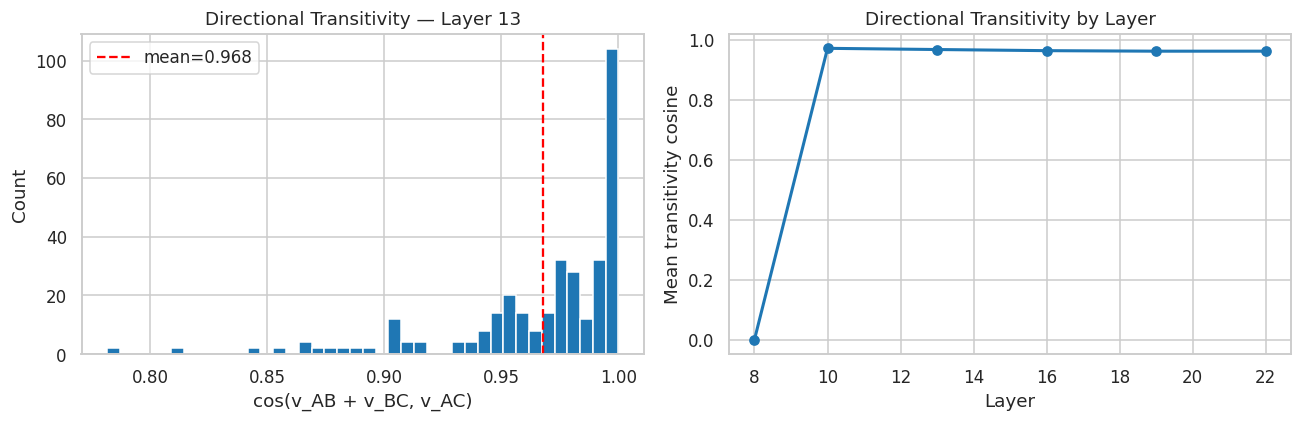

In [6]:
# Distribution of transitivity cosines at primary layer
pri_trans = df_trans[df_trans['layer'] == PRIMARY_LAYER]['cos_transitivity']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pri_trans, bins=40, edgecolor='white')
axes[0].axvline(pri_trans.mean(), color='red', linestyle='--',
                label=f'mean={pri_trans.mean():.3f}')
axes[0].set_xlabel('cos(v_AB + v_BC, v_AC)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Directional Transitivity — Layer {PRIMARY_LAYER}')
axes[0].legend()

mean_by_layer = df_trans.groupby('layer')['cos_transitivity'].mean()
axes[1].plot(mean_by_layer.index, mean_by_layer.values, marker='o', linewidth=2)
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Mean transitivity cosine')
axes[1].set_title('Directional Transitivity by Layer')

plt.tight_layout()
plt.savefig(OUT_DIR / 'caa_transitivity.png', bbox_inches='tight')
plt.show()

In [7]:
# Which triplets have the highest and lowest transitivity?
pri = df_trans[df_trans['layer'] == PRIMARY_LAYER].copy()
pri['triplet'] = pri['A'] + '→' + pri['B'] + '→' + pri['C']
print('Top 10 most transitive triplets:')
print(pri.nlargest(10, 'cos_transitivity')[['triplet', 'cos_transitivity']].to_string(index=False))
print('\nBottom 10 least transitive triplets:')
print(pri.nsmallest(10, 'cos_transitivity')[['triplet', 'cos_transitivity']].to_string(index=False))

Top 10 most transitive triplets:
               triplet  cos_transitivity
     joy→disgust→trust          1.000000
     trust→disgust→joy          1.000000
  surprise→trust→anger          0.999985
  anger→trust→surprise          0.999985
joy→anticipation→trust          0.999976
trust→anticipation→joy          0.999976
 joy→anticipation→fear          0.999974
 fear→anticipation→joy          0.999974
    fear→trust→sadness          0.999971
    sadness→trust→fear          0.999971

Bottom 10 least transitive triplets:
                     triplet  cos_transitivity
         trust→anger→disgust          0.781592
         disgust→anger→trust          0.781592
           joy→anger→disgust          0.809277
           disgust→anger→joy          0.809277
  disgust→anger→anticipation          0.842743
  anticipation→anger→disgust          0.842743
      surprise→anger→disgust          0.852908
      disgust→anger→surprise          0.852908
sadness→disgust→anticipation          0.863635
anticipa

---
## 4. 線形補間テスト — 中間感情の存在

感情AとBのCAAベクトルを線形補間した中間点 `α·caa(A) + (1-α)·caa(B)` は、
感情的に「AとBの中間」と解釈できるか？

これを**3つの側面**から検証する:
1. 補間点の方向は他の感情方向から等距離か？（真に中間に位置するか）
2. Plutchikが「複合感情」として定義したペアでは補間が意味をなすか？
   - joy + trust → love (anticipation に近い？)
   - joy + fear → guilt (surprise に近い？)
3. 等間隔補間 α=0, 0.25, 0.5, 0.75, 1.0 での最近接感情の変化

In [8]:
V = get_pooled(PRIMARY_LAYER)  # (8, D)

# Plutchik's dyads (complex emotions from combining adjacent primary emotions)
PLUTCHIK_DYADS = {
    'love':        ('joy',          'trust'),
    'submission':  ('trust',        'fear'),
    'awe':         ('fear',         'surprise'),
    'disapproval': ('surprise',     'sadness'),
    'remorse':     ('sadness',      'disgust'),
    'contempt':    ('disgust',      'anger'),
    'aggressiveness': ('anger',     'anticipation'),
    'optimism':    ('anticipation', 'joy'),
}

print('=== Plutchik Dyad Test: midpoint of A and B ===')
print('(Nearest emotion to the midpoint vector)\n')

rows_dyad = []
for dyad_name, (emo_a, emo_b) in PLUTCHIK_DYADS.items():
    ia, ib = EMO_POS[emo_a], EMO_POS[emo_b]
    midpoint = unit(V[ia] + V[ib])  # unit-normed midpoint
    # Cosine similarity to all 8 emotions
    sims = V @ midpoint             # (8,)  (V already unit-normed)
    # Exclude the two source emotions from ranking
    sims_excl = sims.copy()
    sims_excl[ia] = -999
    sims_excl[ib] = -999
    nearest     = EMOTION_ORDER[np.argmax(sims)]
    nearest_exc = EMOTION_ORDER[np.argmax(sims_excl)]
    print(f'{dyad_name:16s} ({emo_a}+{emo_b}):  '
          f'nearest={nearest} ({sims[np.argmax(sims)]:.3f})  '
          f'nearest_excl={nearest_exc} ({sims[np.argmax(sims_excl)]:.3f})')
    rows_dyad.append({
        'dyad': dyad_name, 'emo_a': emo_a, 'emo_b': emo_b,
        'nearest': nearest, 'nearest_excl': nearest_exc,
        'sim_nearest': float(sims.max()),
        'sim_nearest_excl': float(sims[np.argmax(sims_excl)]),
    })

pd.DataFrame(rows_dyad).to_csv(OUT_DIR / 'caa_plutchik_dyads.csv', index=False)

=== Plutchik Dyad Test: midpoint of A and B ===
(Nearest emotion to the midpoint vector)

love             (joy+trust):  nearest=trust (0.998)  nearest_excl=anticipation (0.992)
submission       (trust+fear):  nearest=trust (0.996)  nearest_excl=anticipation (0.995)
awe              (fear+surprise):  nearest=fear (0.995)  nearest_excl=sadness (0.994)
disapproval      (surprise+sadness):  nearest=sadness (0.996)  nearest_excl=disgust (0.994)
remorse          (sadness+disgust):  nearest=sadness (0.999)  nearest_excl=anger (0.997)
contempt         (disgust+anger):  nearest=disgust (0.999)  nearest_excl=sadness (0.995)
aggressiveness   (anger+anticipation):  nearest=anger (0.995)  nearest_excl=sadness (0.995)
optimism         (anticipation+joy):  nearest=anticipation (0.998)  nearest_excl=trust (0.994)


In [9]:
# Continuous interpolation between all pairs
ALPHAS = np.linspace(0, 1, 9)  # 0, 0.125, ..., 1

rows_interp = []
for a, b in combinations(range(N_EMO), 2):
    for alpha in ALPHAS:
        interp = unit(alpha * V[a] + (1 - alpha) * V[b])
        sims   = V @ interp                # (8,)
        nearest_idx = np.argmax(sims)
        rows_interp.append({
            'emo_a': EMOTION_ORDER[a],
            'emo_b': EMOTION_ORDER[b],
            'alpha': alpha,
            'nearest': EMOTION_ORDER[nearest_idx],
            'sim': float(sims[nearest_idx]),
        })

df_interp = pd.DataFrame(rows_interp)

# For each pair: at what alpha does the nearest switch from A to B?
print('=== Interpolation Switch Points (alpha where nearest changes) ===')
for a, b in [('joy', 'sadness'), ('fear', 'anger'), ('joy', 'fear'), ('trust', 'disgust')]:
    sub = df_interp[(df_interp['emo_a'] == a) & (df_interp['emo_b'] == b)]
    nearest_seq = sub[['alpha', 'nearest']].values
    print(f'\n{a} → {b} (α=0 is {a}, α=1 is {b}):')
    for alpha, nearest in nearest_seq:
        print(f'  α={alpha:.3f}  nearest={nearest}')

=== Interpolation Switch Points (alpha where nearest changes) ===

joy → sadness (α=0 is joy, α=1 is sadness):
  α=0.000  nearest=sadness
  α=0.125  nearest=sadness
  α=0.250  nearest=sadness
  α=0.375  nearest=sadness
  α=0.500  nearest=sadness
  α=0.625  nearest=joy
  α=0.750  nearest=joy
  α=0.875  nearest=joy
  α=1.000  nearest=joy

fear → anger (α=0 is fear, α=1 is anger):
  α=0.000  nearest=anger
  α=0.125  nearest=anger
  α=0.250  nearest=anger
  α=0.375  nearest=anger
  α=0.500  nearest=anger
  α=0.625  nearest=fear
  α=0.750  nearest=fear
  α=0.875  nearest=fear
  α=1.000  nearest=fear

joy → fear (α=0 is joy, α=1 is fear):
  α=0.000  nearest=fear
  α=0.125  nearest=fear
  α=0.250  nearest=fear
  α=0.375  nearest=fear
  α=0.500  nearest=anticipation
  α=0.625  nearest=joy
  α=0.750  nearest=joy
  α=0.875  nearest=joy
  α=1.000  nearest=joy

trust → disgust (α=0 is trust, α=1 is disgust):
  α=0.000  nearest=disgust
  α=0.125  nearest=disgust
  α=0.250  nearest=disgust
  α=0.375

---
## 5. Circumplex モデル適合 — 感情は2D円状に並ぶか？

VAD（Valence-Arousal-Dominance）モデルや感情円環モデル（Russell's Circumplex）では、
感情は2次元平面上の円上に配置される。

CAA方向の2D PCA投影が**円に近い分布**をなすかを定量的に検証する:
- 各点の原点からの距離の標準偏差（低いほど円に近い）
- 等角間隔からのずれ（Plutchikの8等分配置と比較）

In [10]:
V = get_pooled(PRIMARY_LAYER)  # (8, D)
pca2 = PCA(n_components=2)
V2 = pca2.fit_transform(V)     # (8, 2)
evr = pca2.explained_variance_ratio_

# Normalize to unit circle for circular analysis
radii   = np.linalg.norm(V2, axis=1)  # (8,)
angles  = np.arctan2(V2[:, 1], V2[:, 0])  # (8,) in [-pi, pi]
angles_sorted_idx = np.argsort(angles)

print(f'PCA 2D EVR: {evr[0]:.3f} + {evr[1]:.3f} = {evr.sum():.3f}')
print(f'\nRadii (distance from origin in PCA space):')
print(f'  mean={radii.mean():.4f}, std={radii.std():.4f}, cv={radii.std()/radii.mean():.4f}')
print(f'  (cv=0 means perfect circle)')

print(f'\nAngle order (counterclockwise):')
for i in angles_sorted_idx:
    print(f'  {EMOTION_ORDER[i]:15s}  angle={np.degrees(angles[i]):+7.1f}°  radius={radii[i]:.4f}')

# Expected equal-spacing angles for 8 emotions: 360/8 = 45°
sorted_angles = angles[angles_sorted_idx]
angle_diffs   = np.diff(np.append(sorted_angles, sorted_angles[0] + 2*np.pi))
print(f'\nAngle gaps (ideal=45°): {np.degrees(angle_diffs).round(1).tolist()}')
print(f'Std of angle gaps: {np.degrees(angle_diffs).std():.2f}°  (0° = perfect equal spacing)')

PCA 2D EVR: 0.437 + 0.232 = 0.669

Radii (distance from origin in PCA space):
  mean=0.0892, std=0.0213, cv=0.2390
  (cv=0 means perfect circle)

Angle order (counterclockwise):
  joy              angle= -160.9°  radius=0.1054
  surprise         angle=  -80.7°  radius=0.1248
  anger            angle=   +2.9°  radius=0.0897
  disgust          angle=   +4.8°  radius=0.0798
  sadness          angle=  +20.4°  radius=0.0508
  fear             angle=  +61.1°  radius=0.0745
  anticipation     angle= +147.4°  radius=0.0822
  trust            angle= +169.5°  radius=0.1060

Angle gaps (ideal=45°): [80.19999694824219, 83.5999984741211, 1.7999999523162842, 15.699999809265137, 40.599998474121094, 86.30000305175781, 22.100000381469727, 29.600000381469727]
Std of angle gaps: 31.50°  (0° = perfect equal spacing)


Fitted circle center: (-0.0100, -0.0278),  radius: 0.0963
Mean residual from circle: 0.0077  (0 = perfect circle)
Max  residual from circle: 0.0228


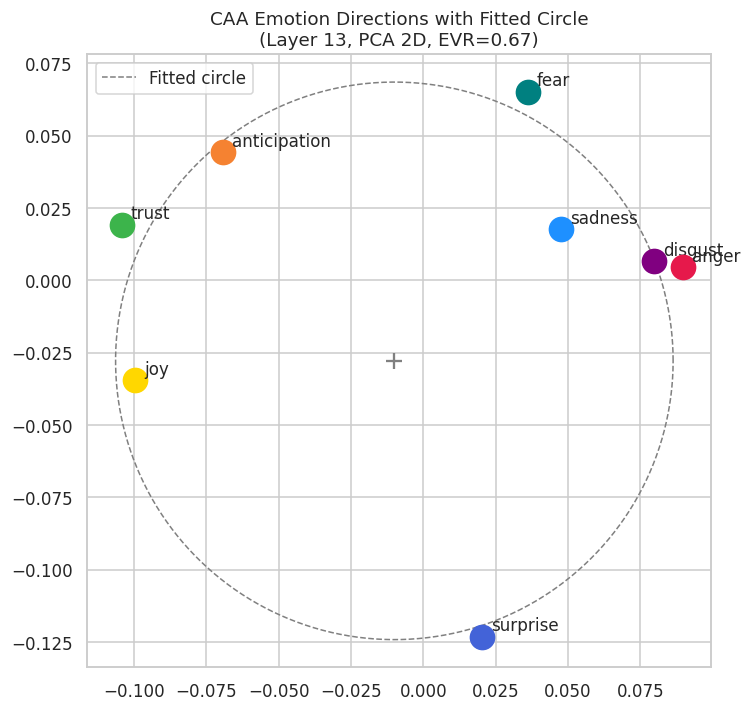

In [11]:
# Fit a circle to the 2D PCA points using least-squares
def fit_circle(points):
    """Algebraic circle fit. Returns (cx, cy, r)."""
    x, y = points[:, 0], points[:, 1]
    A = np.column_stack([2*x, 2*y, np.ones(len(x))])
    b = x**2 + y**2
    sol, *_ = np.linalg.lstsq(A, b, rcond=None)
    cx, cy = sol[0], sol[1]
    r = np.sqrt(sol[2] + cx**2 + cy**2)
    residuals = np.abs(np.sqrt((x - cx)**2 + (y - cy)**2) - r)
    return cx, cy, r, residuals

cx, cy, r, residuals = fit_circle(V2)
print(f'Fitted circle center: ({cx:.4f}, {cy:.4f}),  radius: {r:.4f}')
print(f'Mean residual from circle: {residuals.mean():.4f}  (0 = perfect circle)')
print(f'Max  residual from circle: {residuals.max():.4f}')

EMO_COLORS = {
    'joy': '#FFD700', 'trust': '#3cb44b', 'fear': '#008080',
    'surprise': '#4363d8', 'sadness': '#1e90ff', 'disgust': '#800080',
    'anger': '#e6194b', 'anticipation': '#f58231',
}

fig, ax = plt.subplots(figsize=(7, 7))
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(cx + r*np.cos(theta), cy + r*np.sin(theta),
        'gray', linestyle='--', linewidth=1, label='Fitted circle')
ax.scatter([cx], [cy], marker='+', s=100, color='gray')
for i, emo in enumerate(EMOTION_ORDER):
    c = EMO_COLORS.get(emo, 'gray')
    ax.scatter(V2[i, 0], V2[i, 1], s=250, color=c, zorder=3)
    ax.annotate(emo, (V2[i, 0], V2[i, 1]),
                textcoords='offset points', xytext=(6, 4), fontsize=11)
ax.set_aspect('equal')
ax.set_title(f'CAA Emotion Directions with Fitted Circle\n'
             f'(Layer {PRIMARY_LAYER}, PCA 2D, EVR={evr.sum():.2f})')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'caa_circumplex_fit.png', bbox_inches='tight')
plt.show()

---
## 6. 全ペア遷移ベクトルの一貫性ヒートマップ

全28ペアの遷移ベクトル `v(A→B)` について、
異なるレイヤー間でこの方向がどれだけ一貫しているかを測定する。
一貫性が高い = 感情の相対的な位置関係がレイヤーをまたいで安定

In [12]:
# Build (28, D) transition direction matrix for each layer
pairs = list(combinations(range(N_EMO), 2))
pair_labels = [f'{EMOTION_ORDER[a]}→{EMOTION_ORDER[b]}' for a, b in pairs]

rows_pair_cos = []
V_layers = {l: get_pooled(l) for l in LAYER_INDICES}

for l1, l2 in combinations(LAYER_INDICES, 2):
    V1, V2 = V_layers[l1], V_layers[l2]
    for ia, ib in pairs:
        v1 = unit(V1[ib] - V1[ia])
        v2 = unit(V2[ib] - V2[ia])
        c  = float(v1 @ v2)
        rows_pair_cos.append({
            'layer_1': l1, 'layer_2': l2,
            'pair': f'{EMOTION_ORDER[ia]}↔{EMOTION_ORDER[ib]}',
            'cosine': c,
        })

df_pair_cos = pd.DataFrame(rows_pair_cos)

# Cross-layer consistency for layer 8 vs 13 vs 22
for ref_layer in [LAYER_INDICES[0], PRIMARY_LAYER, LAYER_INDICES[-1]]:
    others = [l for l in LAYER_INDICES if l != ref_layer]
    sub = df_pair_cos[((df_pair_cos['layer_1'] == ref_layer) |
                       (df_pair_cos['layer_2'] == ref_layer))]
    m = sub.groupby('pair')['cosine'].mean().mean()
    print(f'Mean transition direction consistency with layer {ref_layer}: {m:.4f}')

Mean transition direction consistency with layer 8: 0.0000
Mean transition direction consistency with layer 13: 0.3747
Mean transition direction consistency with layer 22: 0.3795


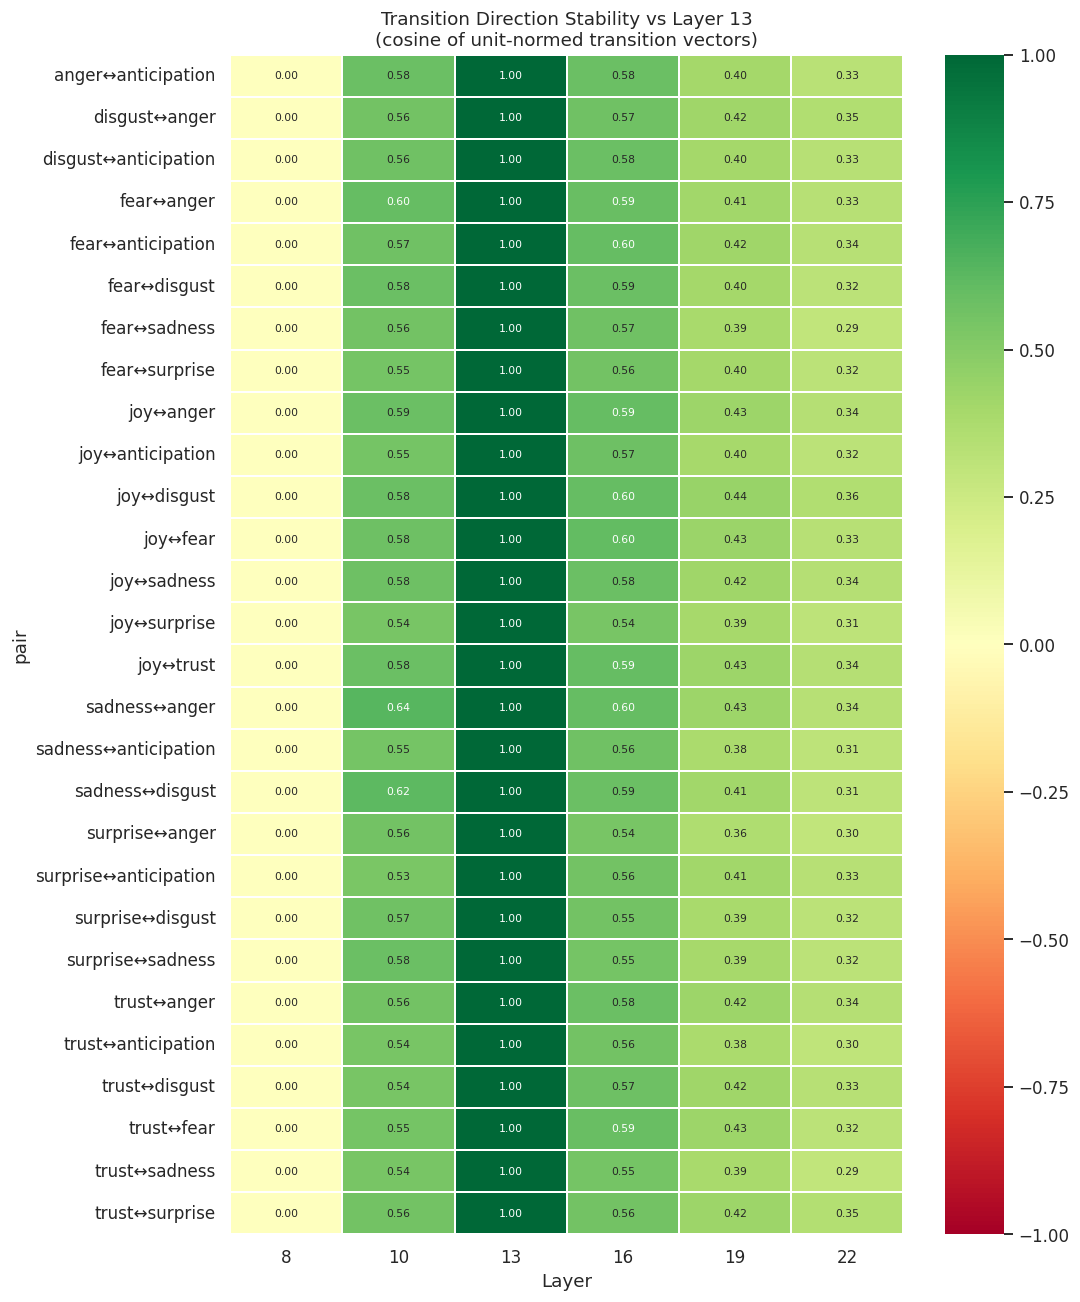

Done. Outputs saved to /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/manifold_linearity


In [13]:
# Heatmap: mean cross-layer consistency per pair, relative to primary layer
V_p = get_pooled(PRIMARY_LAYER)
rows_stability = []
for layer in LAYER_INDICES:
    V_l = get_pooled(layer)
    for ia, ib in pairs:
        v_p = unit(V_p[ib] - V_p[ia])
        v_l = unit(V_l[ib] - V_l[ia])
        rows_stability.append({
            'layer': layer,
            'pair': f'{EMOTION_ORDER[ia]}↔{EMOTION_ORDER[ib]}',
            'cosine': float(v_p @ v_l),
        })

df_stab = pd.DataFrame(rows_stability)
pivot = df_stab.pivot(index='pair', columns='layer', values='cosine')

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.3,
            annot_kws={'size': 7})
ax.set_title(f'Transition Direction Stability vs Layer {PRIMARY_LAYER}\n'
             f'(cosine of unit-normed transition vectors)')
ax.set_xlabel('Layer')
plt.tight_layout()
plt.savefig(OUT_DIR / 'caa_transition_stability_heatmap.png', bbox_inches='tight')
plt.show()

df_stab.to_csv(OUT_DIR / 'caa_transition_stability.csv', index=False)
print('Done. Outputs saved to', OUT_DIR)

---
## 7. 3段階分解: 全体的感情化方向 / 共有感情軸 / 感情固有残差

### 問題: 素朴な PCA 分解のバイアス

`sklearn.PCA` は内部でデータを**平均中心化**するため、上位 K 成分は `mean(V)` を引いた後の分散を説明する。  
各ベクトル `v_e`（unit-normed、∴ `||v_e||²=1`）のうち**大半は平均方向に揃っている**が、  
PCA 成分にはその方向が含まれない → `ratio_shared ≈ 1%` という過小推定が生じる。

### 修正: 明示的 3 段階分解

$$
v_e = \underbrace{\alpha_e \, \hat{\mu}}_{\text{① 全体的感情化}} 
    + \underbrace{\sum_{k=1}^{K} \beta_{ek} \, u_k}_{\text{② 共有感情軸（VAD 的）}} 
    + \underbrace{\varepsilon_e}_{\text{③ 感情固有残差}}
$$

- **① 全体的感情化方向** `û_mu = unit(mean(V))`  
  全 8 感情に共通する「ベーステキストを感情的にする」方向。  
- **② 共有感情軸** `{u_k}`  
  `û_mu` を除去した残差に対する PCA の上位 K 成分 → valence / arousal / dominance 的な軸。  
  `mean(V_defl) ≈ 0` が保証されるため sklearn の centering は無害。  
- **③ 感情固有残差**  
  ① + ② で説明できない成分。

> **Note**: `mean(V_defl) = mean(V) − ||mean(V)|| · û_mu = 0` となることから、  
> deflation 後の PCA は追加の centering なしに clean な分解を与える。


In [14]:
V = get_pooled(PRIMARY_LAYER)  # (8, D) unit-normed

# ── Step 1: Global mean emotionalization direction ─────────────────────────────
mu   = V.mean(axis=0)            # (D,) — centroid of all 8 CAA vectors
u_mu = unit(mu)                  # unit-normed global mean direction

proj_global = V @ u_mu           # (8,) — scalar projection of each v_e onto û_mu
print(f'Global mean direction (û_mu) projections per emotion (layer {PRIMARY_LAYER}):')
for emo, p in sorted(zip(EMOTION_ORDER, proj_global), key=lambda x: -x[1]):
    print(f'  {emo:15s}: {p:.4f}')

ratio_global_per_emo = proj_global ** 2  # ||v_e||²=1, so ratio = proj²
print(f'\nFraction of ||v_e||² in global mean direction:')
print(f'  mean={ratio_global_per_emo.mean():.4f}  '
      f'std={ratio_global_per_emo.std():.4f}  '
      f'min={ratio_global_per_emo.min():.4f}  '
      f'max={ratio_global_per_emo.max():.4f}')

# ── Step 2: Deflate global mean component ────────────────────────────────────
# v_e_defl = v_e − (v_e · û_mu) û_mu  →  lies in û_mu's orthogonal complement
V_defl = V - np.outer(proj_global, u_mu)   # (8, D)

# Sanity: mean of deflated vectors should be ~0
print(f'\n||mean(V_defl)||: {np.linalg.norm(V_defl.mean(axis=0)):.2e}  (should be ≈0)')

# ── Step 3: PCA on mean-deflated vectors ─────────────────────────────────────
# mean(V_defl)=0 analytically, so sklearn centering is harmless
K_max = N_EMO - 1  # 7 (at most 7 non-trivial PCs for 8 vectors)
pca_defl = PCA(n_components=K_max)
pca_defl.fit(V_defl)
evr_defl  = pca_defl.explained_variance_ratio_   # (7,)
cum_evr_defl = np.cumsum(evr_defl)
U_defl = pca_defl.components_                     # (7, D)

print(f'\nScree of û_mu-deflated CAA PCA (layer {PRIMARY_LAYER}):')
for k, (e, c) in enumerate(zip(evr_defl, cum_evr_defl), 1):
    print(f'  PC{k}: EVR={e:.4f}  cumEVR={c:.4f}')

# ── Step 4: 3-way decomposition per emotion for K=0..K_max ──────────────────
rows_decomp = []
for k in range(0, K_max + 1):
    U_k = U_defl[:k]  # (k, D)
    for e, emo in enumerate(EMOTION_ORDER):
        v_e   = V[e]                             # (D,) unit-normed
        # ① global mean component
        v_g   = proj_global[e] * u_mu            # (D,)
        # ② shared affective axes (project DEFLATED residual onto top-k PCs)
        v_res = V_defl[e]                        # (D,) = v_e - v_g
        if k > 0:
            coords_k = U_k @ v_res               # (k,)  coords in PCA space
            v_shared = U_k.T @ coords_k          # (D,)  back-projection
        else:
            v_shared = np.zeros(D)
        # ③ emotion-specific residual
        v_spec = v_res - v_shared                 # (D,)

        nt = float(np.dot(v_e, v_e))             # =1 for unit vectors
        rows_decomp.append({
            'k':               k,
            'emotion':         emo,
            'ratio_global':    float(np.dot(v_g,      v_g))   / (nt + 1e-12),
            'ratio_shared':    float(np.dot(v_shared,  v_shared)) / (nt + 1e-12),
            'ratio_specific':  float(np.dot(v_spec,   v_spec))  / (nt + 1e-12),
        })

df_decomp = pd.DataFrame(rows_decomp)

# ── Summary at representative K values ───────────────────────────────────────
print('\n3-way decomposition summary:')
print(f'{"K":>3}  {"ratio_global":>12}  {"ratio_shared":>12}  {"ratio_specific":>14}  {"cumEVR_defl":>11}')
for k_show in [0, 1, 2, 3, 4, K_max]:
    sub = df_decomp[df_decomp['k'] == k_show]
    rg  = sub['ratio_global'].mean()
    rs  = sub['ratio_shared'].mean()
    rsp = sub['ratio_specific'].mean()
    cev = cum_evr_defl[k_show - 1] if k_show > 0 else 0.0
    print(f'{k_show:>3}  {rg:>12.4f}  {rs:>12.4f}  {rsp:>14.4f}  {cev:>11.4f}')

df_decomp.to_csv(OUT_DIR / 'caa_3way_decomposition.csv', index=False)


Global mean direction (û_mu) projections per emotion (layer 13):
  sadness        : 0.9965
  disgust        : 0.9954
  fear           : 0.9946
  anticipation   : 0.9942
  anger          : 0.9941
  joy            : 0.9923
  trust          : 0.9917
  surprise       : 0.9908

Fraction of ||v_e||² in global mean direction:
  mean=0.9874  std=0.0036  min=0.9817  max=0.9930

||mean(V_defl)||: 7.75e-08  (should be ≈0)

Scree of û_mu-deflated CAA PCA (layer 13):
  PC1: EVR=0.4371  cumEVR=0.4371
  PC2: EVR=0.2320  cumEVR=0.6691
  PC3: EVR=0.1434  cumEVR=0.8125
  PC4: EVR=0.0803  cumEVR=0.8927
  PC5: EVR=0.0580  cumEVR=0.9507
  PC6: EVR=0.0351  cumEVR=0.9858
  PC7: EVR=0.0142  cumEVR=1.0000

3-way decomposition summary:
  K  ratio_global  ratio_shared  ratio_specific  cumEVR_defl
  0        0.9874        0.0000          0.0126       0.0000
  1        0.9874        0.0055          0.0071       0.4371
  2        0.9874        0.0084          0.0042       0.6691
  3        0.9874        0.0102     

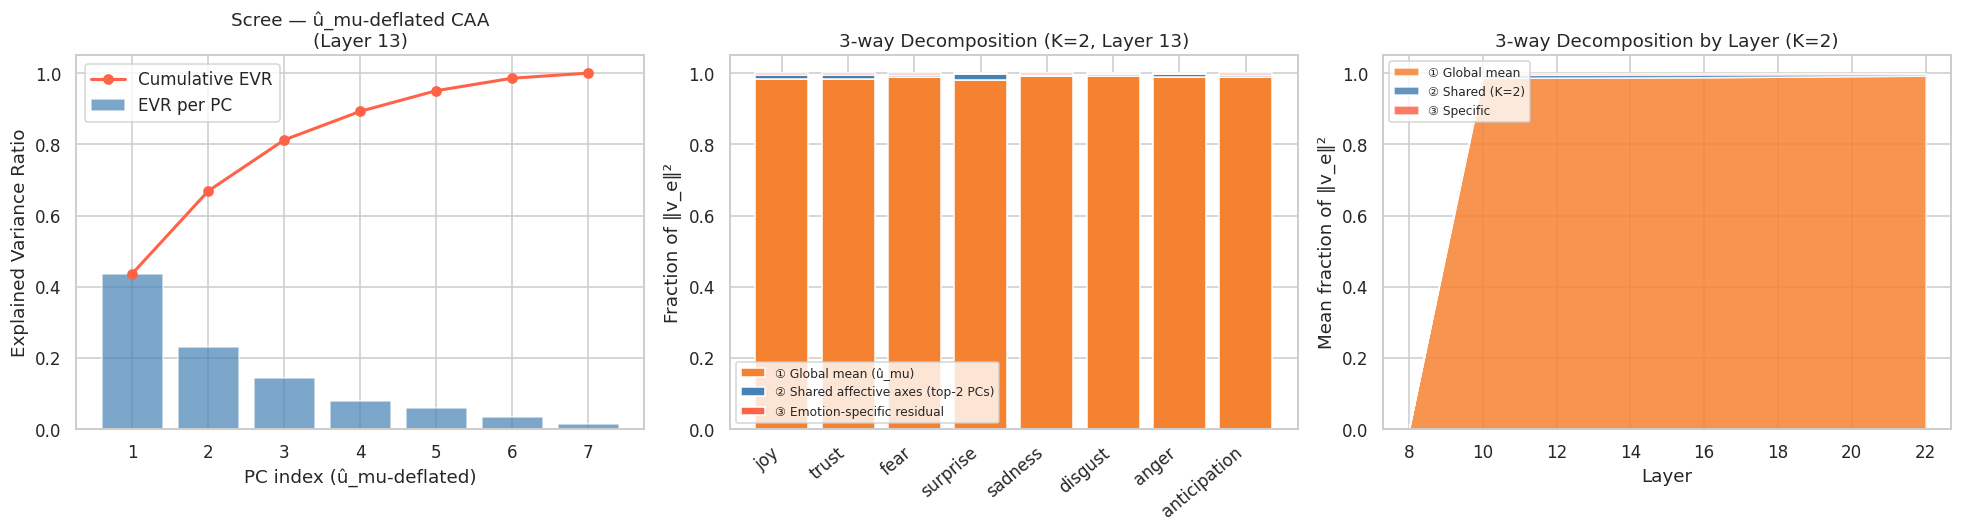

Done. Outputs saved to /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/manifold_linearity


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Left: Scree of deflated PCA ───────────────────────────────────────────────
axes[0].bar(range(1, K_max + 1), evr_defl,      label='EVR per PC',     color='steelblue', alpha=0.7)
axes[0].plot(range(1, K_max + 1), cum_evr_defl, marker='o', color='tomato',
             label='Cumulative EVR', linewidth=2)
axes[0].set_xlabel('PC index (û_mu-deflated)')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title(f'Scree — û_mu-deflated CAA\n(Layer {PRIMARY_LAYER})')
axes[0].set_xticks(range(1, K_max + 1))
axes[0].legend()

# ── Middle: Stacked bar (3-way) at K=2 ───────────────────────────────────────
K_SHOW = 2
sub2   = df_decomp[df_decomp['k'] == K_SHOW].set_index('emotion').loc[EMOTION_ORDER]
x      = np.arange(N_EMO)

axes[1].bar(x, sub2['ratio_global'],   label='① Global mean (û_mu)',            color='#f58231')
axes[1].bar(x, sub2['ratio_shared'],
            bottom=sub2['ratio_global'],
            label=f'② Shared affective axes (top-{K_SHOW} PCs)', color='steelblue')
axes[1].bar(x, sub2['ratio_specific'],
            bottom=sub2['ratio_global'] + sub2['ratio_shared'],
            label='③ Emotion-specific residual',                  color='tomato')
axes[1].set_xticks(x)
axes[1].set_xticklabels(EMOTION_ORDER, rotation=40, ha='right')
axes[1].set_ylabel('Fraction of ‖v_e‖²')
axes[1].set_ylim(0, 1.05)
axes[1].set_title(f'3-way Decomposition (K={K_SHOW}, Layer {PRIMARY_LAYER})')
axes[1].legend(fontsize=8)

# ── Right: Mean ratio_global / ratio_shared(K=2) / ratio_specific by layer ───
rows_by_layer = []
for layer in LAYER_INDICES:
    V_l  = get_pooled(layer)
    mu_l = V_l.mean(axis=0)
    u_mu_l = unit(mu_l)
    proj_g_l = V_l @ u_mu_l
    V_defl_l = V_l - np.outer(proj_g_l, u_mu_l)
    pca_l = PCA(n_components=K_SHOW)
    pca_l.fit(V_defl_l)
    U_l = pca_l.components_
    rg_list, rs_list, rsp_list = [], [], []
    for e in range(N_EMO):
        v_e   = V_l[e]
        v_g   = proj_g_l[e] * u_mu_l
        v_res = V_defl_l[e]
        coords = U_l @ v_res
        v_sh   = U_l.T @ coords
        v_sp   = v_res - v_sh
        nt = float(np.dot(v_e, v_e))
        rg_list.append(float(np.dot(v_g,  v_g))  / (nt + 1e-12))
        rs_list.append(float(np.dot(v_sh, v_sh)) / (nt + 1e-12))
        rsp_list.append(float(np.dot(v_sp, v_sp)) / (nt + 1e-12))
    rows_by_layer.append({'layer': layer,
                          'ratio_global':   np.mean(rg_list),
                          'ratio_shared':   np.mean(rs_list),
                          'ratio_specific': np.mean(rsp_list)})

df_by_layer = pd.DataFrame(rows_by_layer)
ax3 = axes[2]
ax3.stackplot(df_by_layer['layer'],
              df_by_layer['ratio_global'],
              df_by_layer['ratio_shared'],
              df_by_layer['ratio_specific'],
              labels=['① Global mean', f'② Shared (K={K_SHOW})', '③ Specific'],
              colors=['#f58231', 'steelblue', 'tomato'], alpha=0.85)
ax3.set_xlabel('Layer')
ax3.set_ylabel('Mean fraction of ‖v_e‖²')
ax3.set_title(f'3-way Decomposition by Layer (K={K_SHOW})')
ax3.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'caa_3way_decomposition.png', bbox_inches='tight')
plt.show()

df_by_layer.to_csv(OUT_DIR / 'caa_3way_decomposition_by_layer.csv', index=False)
print('Done. Outputs saved to', OUT_DIR)
